In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
all_data = pd.read_csv('tables/trkeDID_pits_over.csv')

In [18]:
all_data.columns

Index(['season', 'round', 'drivers_num', 'position_quali', 'position_race',
       'status', 'driver', 'constructor', 'grid', 'laps', 'total_time_ms',
       'points', 'driverId', 'race_name', 'circuit', ' lap_length',
       ' number_of_laps', ' number_of_corners', 'AirTemp', 'Humidity',
       'Pressure', 'TrackTemp', 'WindSpeed', 'rain_bin', 'wind_direction',
       'is_sprint_weekend', 'last_year_time', 'avg_position_last5',
       'num_dnfs_last5', 'avg_gained_lost_last5', 'num_pit_stops',
       'lap_pit_stops', 'duration_pit_stops', 'num_overtakes'],
      dtype='object')

In [19]:
all_data = all_data.drop(['status', 'driver', 'driverId', 'constructor', 'race_name', 'circuit', 'lap_pit_stops', 'duration_pit_stops', 'points', 'laps', 'total_time_ms'], axis=1)

In [20]:
df = all_data

In [24]:
df = df.fillna(-1)

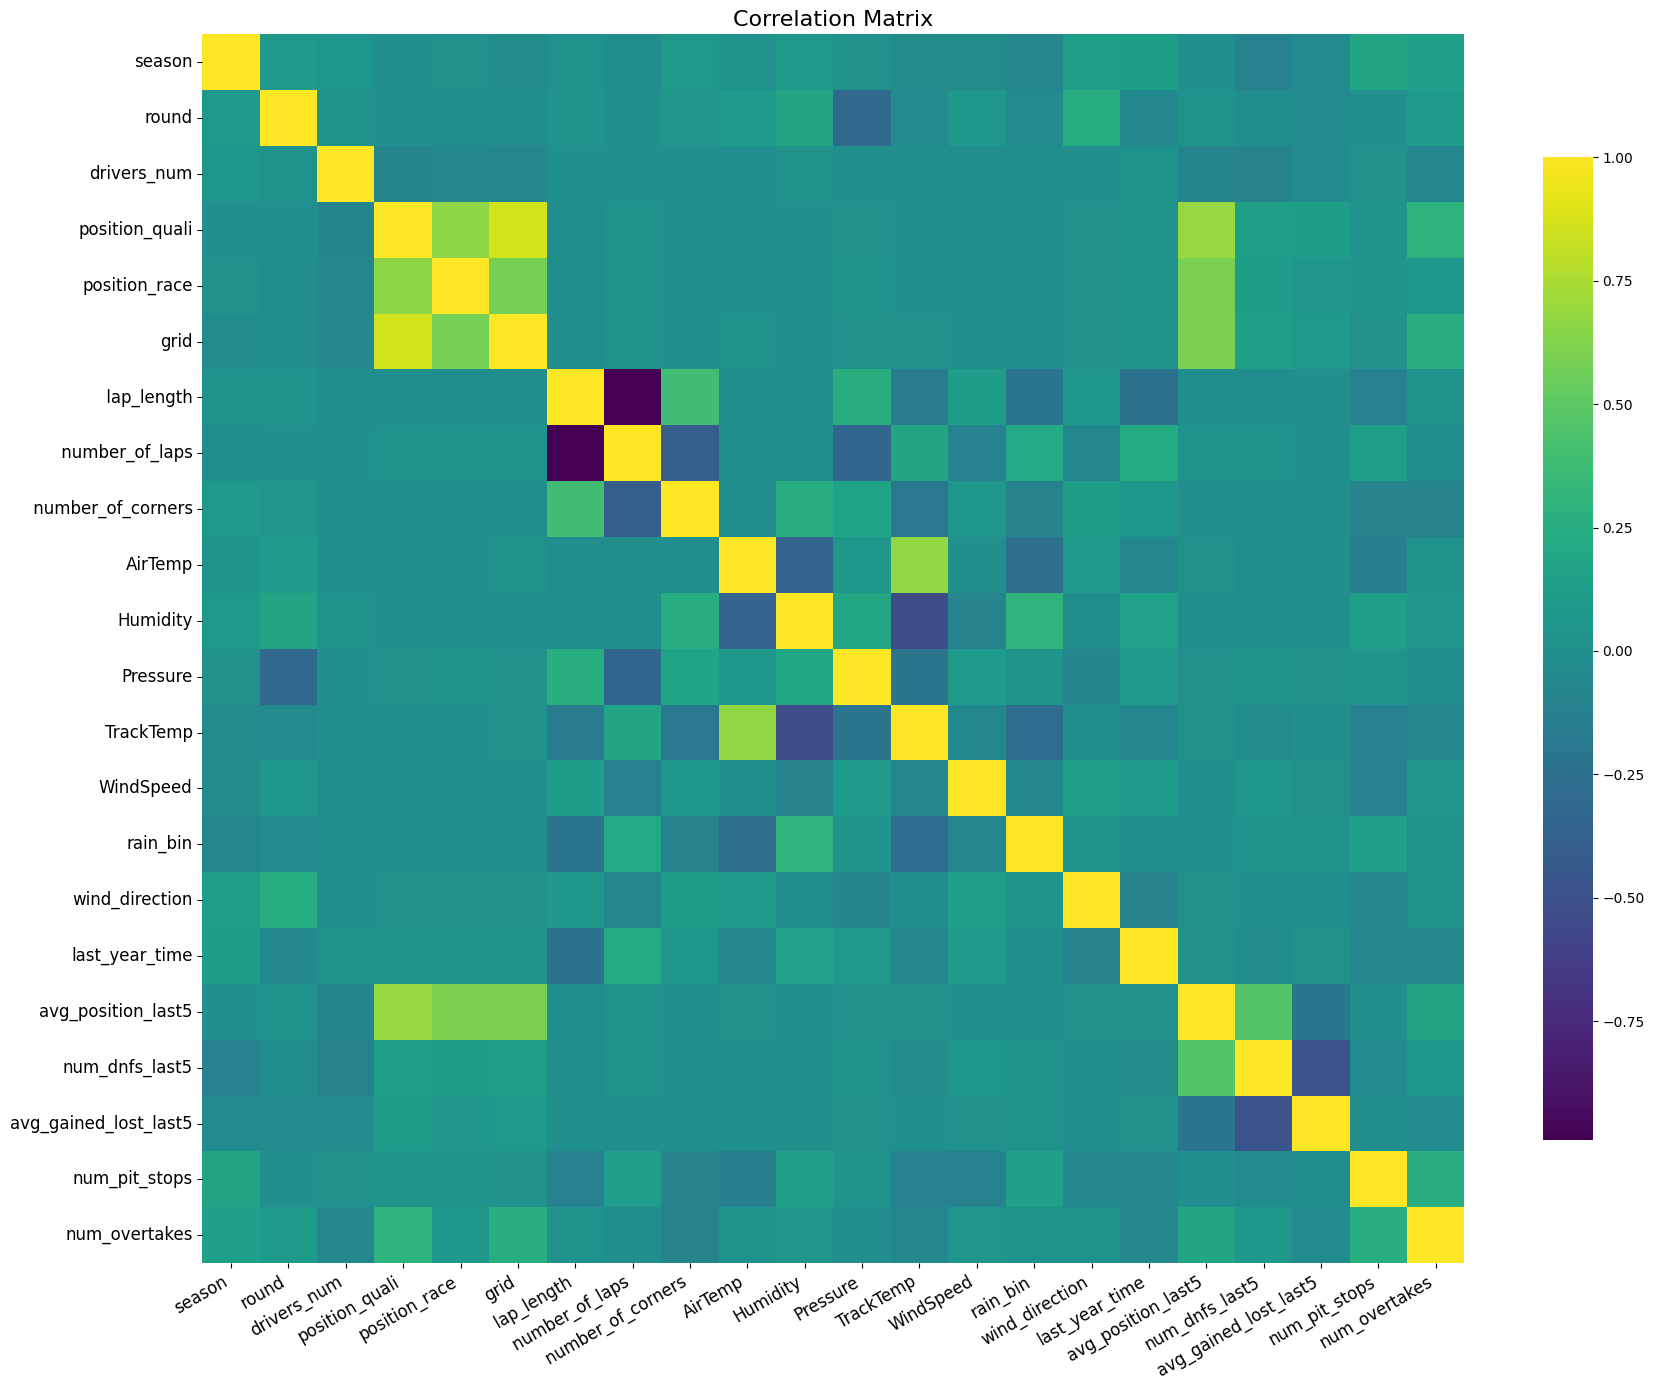

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 14))
corr = df.select_dtypes(['number']).corr()

sns.heatmap(corr, annot=False, fmt=".2f", cmap='viridis',
            xticklabels=True, yticklabels=True, cbar_kws={"shrink": 0.8})

plt.xticks(rotation=30, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.title('Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Feature Importances')

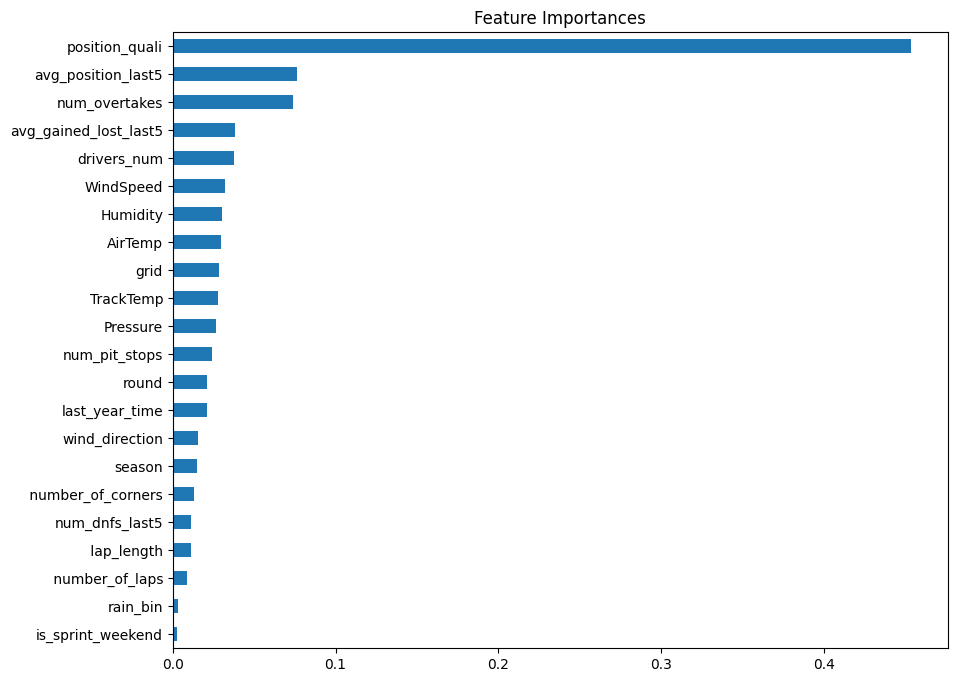

In [26]:
from sklearn.ensemble import RandomForestRegressor

X = df.drop(columns=['position_race'])  # or other target
y = df['position_race']

model = RandomForestRegressor()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 8))
plt.title("Feature Importances")


Text(0.5, 1.0, 'Mutual Information')

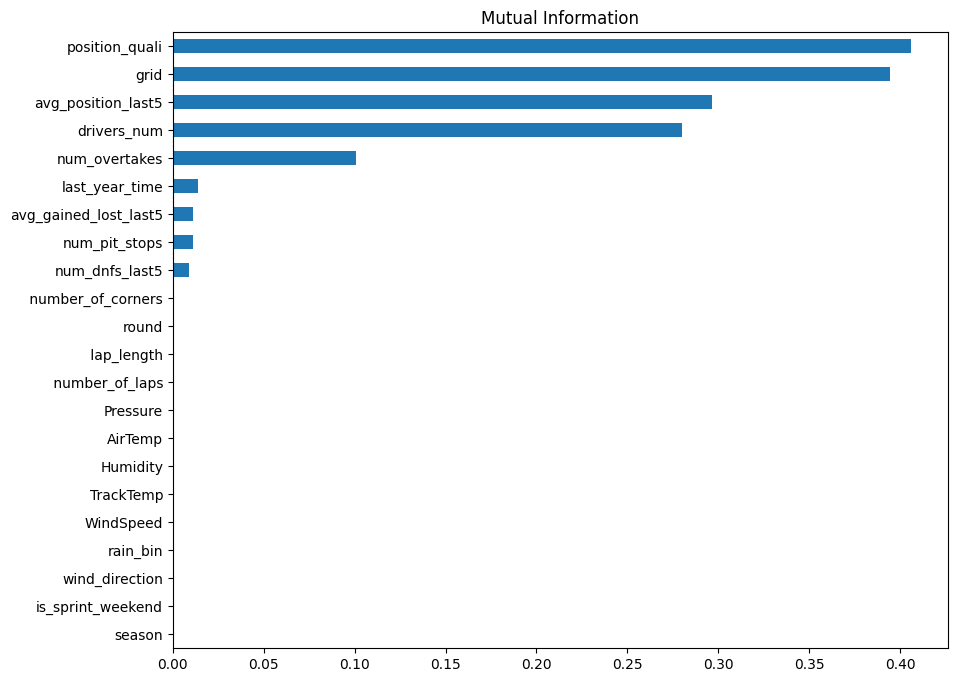

In [27]:
from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(X, y)
mi_series = pd.Series(mi, index=X.columns)
mi_series.sort_values().plot(kind='barh', figsize=(10, 8))
plt.title("Mutual Information")
